A hybrid CNN-BiLSTM-Attention network automatically learns temporal representations from HRV signals, while handcrafted HRV features extracted using tsfresh capture complementary statistical characteristics. These automated and engineered features are fused within a dense neural network for ADHD classification. 

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Reshape, Add, TimeDistributed, BatchNormalization, Bidirectional, Attention, Input, GlobalAveragePooling1D, MultiHeadAttention
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Concatenate
import matplotlib.pyplot as plt

from sklearn import metrics
from collections import defaultdict
import shap


2026-07-23 23:19:22.588389: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784848762.794585      84 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784848762.861514      84 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Paths
_DATASET_ROOT_PATH = '/kaggle/input/hyperaktiv/hyperaktiv'
_PATH_TO_GT = os.path.join(_DATASET_ROOT_PATH, "patient_info.csv")
_PATH_TO_HRV_RAW = '/kaggle/input/hyperaktiv/hyperaktiv/hrv_data'
_PATH_TO_HRV_FEATURES_SEGMENG = os.path.join(_DATASET_ROOT_PATH, "hrv_features_seg")

In [3]:
# Parameters
SEGMENT_LENGTH = 1024  # Number of HRV values per segment
NUM_CLASSES = 1       # Binary classification ADHD VS control groups

# Helper Functions
def load_metadata(path_to_gt):
    """Loads patient metadata."""
    metadata = pd.read_csv(_PATH_TO_GT, sep=";").sort_values(by="ID")
    
    return metadata

def load_hrv_data(path_to_hrv_raw, segment_length):
    """Loads HRV data and segments it into fixed-length sequences."""
    all_segments = []
    labels = []
    
    for filename in os.listdir(path_to_hrv_raw):
        filepath = os.path.join(path_to_hrv_raw, filename)
        patient_id = os.path.splitext(os.path.basename(filepath))[0].split("_")[2] # get patient ID

        # Load HRV data with preprocessing
        hrv_data = pd.read_csv(filepath, sep=';', parse_dates=['TIMESTAMP'])
        hrv_data = hrv_data.iloc[2:]  # Skip the first two rows, keeping the rest
        
        # Replace the last value in "HRV" if it's 2000
        if hrv_data["HRV"].iloc[-1] == 2000:
            mean_hrv = hrv_data["HRV"][hrv_data["HRV"] != 2000].mean()  # Calculate mean, excluding 2000 if present
            hrv_data.loc[hrv_data.index[-1], "HRV"] = mean_hrv

        hrv_data.replace(2000, np.nan, inplace=True)  # replace 2000 with None

        hrv_data["TIMESTAMP"] = pd.to_datetime(hrv_data["TIMESTAMP"])  # Ensure "TIME" is datetime
        hrv_data.set_index("TIMESTAMP", inplace=True)  # Set "TIME" as the index
        
        hrv_data = hrv_data.interpolate(method='time')  # interpolate NaN values

        nan_in_hrv = hrv_data['HRV'].isnull().sum()
        
        if hrv_data["HRV"].isnull().any():
            hrv_data["HRV"] = hrv_data["HRV"].fillna(hrv_data["HRV"].mean())
        
        hrv_values = hrv_data['HRV'].values

        for i in range(0, len(hrv_values) - segment_length + 1, int(segment_length/2)):
            segment = hrv_values[i:i + segment_length]
             all_segments.append(segment)
            labels.append(patient_id)  # Associate segment with patient ID

    return np.array(all_segments), labels


def process_labels(labels, metadata):
    """Maps patient IDs to ADHD or control labels."""
    
    # Ensure the metadata DataFrame is indexed by 'ID' and the types match
    metadata['ID'] = metadata['ID'].astype(str)
    metadata = metadata.set_index('ID')
    labels = [str(pid) for pid in labels]  # Convert labels to strings
    
    # Extract ADHD labels corresponding to the patient IDs in labels
    y = []
    for pid in labels:
        if pid in metadata.index:
            y.append(metadata.loc[pid, 'ADHD'])
        else:
            print(f"Warning: Patient ID {pid} not found in metadata.")
            y.append(None)  # Handle missing IDs gracefully

    return np.array(y)

# Load and preprocess data
metadata = load_metadata(_PATH_TO_GT)
X_hrv, label_ids = load_hrv_data(_PATH_TO_HRV_RAW, SEGMENT_LENGTH)

y = process_labels(label_ids, metadata)

# Normalize HRV data
scaler = StandardScaler()
X_hrv = scaler.fit_transform(X_hrv.reshape(-1, SEGMENT_LENGTH))

# Reshape data for LSTM input: (samples, timesteps, features)
X_hrv = X_hrv.reshape(-1, SEGMENT_LENGTH, 1)

print(X_hrv.shape)
print(y.shape)


(15002, 1024, 1)
(15002,)


In [4]:
# Processing all patients' HRV data - get all handcrafted features
def process_all_patients(HRV_seq_dir):
    patients_HRV_data = []
    labels = []

    # Initialize lists to store feature data and labels
    all_features = []
    all_labels = []

    dataY = pd.read_csv(_PATH_TO_GT, sep=";").sort_values(by="ID")
    # Loop through each file in the directory
    for filename in os.listdir(HRV_seq_dir):
        if filename.endswith('.csv'):
            filepath = os.path.join(HRV_seq_dir, filename)
            one_patient_seq_data = pd.read_csv(filepath, sep=";", header=None)
                
            # Convert DataFrame to NumPy array and append to the list
            feature_array = one_patient_seq_data.to_numpy()
            all_features.append(feature_array)
            
            patient_id = str(int(os.path.splitext(os.path.basename(filepath))[0].split("_")[4])) # get patient ID
            patient_ADHD_label = dataY.loc[dataY['ID'] == int(patient_id), 'ADHD'].values[0]
            
            # Create a label array with the same number of rows as feature_array
            labels_array = np.full((feature_array.shape[0],), patient_ADHD_label)
            all_labels.append(labels_array)
            
    # Stack all feature data and labels into single NumPy arrays
    X = np.vstack(all_features)  # Shape: (total_segments, 28)
    y = np.hstack(all_labels)    # Shape: (total_segments,)            
    
    return X, y

In [5]:
segment_data_dir = _PATH_TO_HRV_FEATURES_SEGMENG
X_hrv_features, labels = process_all_patients(segment_data_dir)
print("Input Features Data Shape: "  + str(X_hrv_features.shape))
print("Train Label Shape: " + str(labels.shape))

Input Features Data Shape: (15002, 28)
Train Label Shape: (15002,)


I0000 00:00:1784848795.469102      84 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784848795.471656      84 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Argument `alpha` is deprecated. Use `negative_slope` instead.
I0000 00:00:1784848808.117970     138 cuda_dnn.cc:529] Loaded cuDNN version 90300


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6826 - loss: 0.5967
Test Accuracy: 0.70


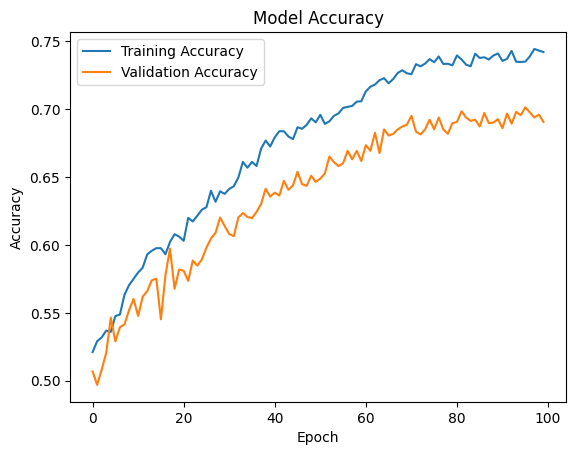

In [6]:
_NUMBER_OF_FOLDS = 10
NUM_FEATURES = 28  # Additional handcrafted HRV features
models = [ ]
test_cv_results = []

histories = []

for i in range(_NUMBER_OF_FOLDS):
    # Train-test split
    X_train, X_test, y_train, y_test, X_features_train, X_features_test = train_test_split(X_hrv, y, X_hrv_features, test_size=0.2, random_state=42)
    
    # Input Layer
    input_signal = Input(shape=(SEGMENT_LENGTH, 1))
    input_features = Input(shape=(NUM_FEATURES,))
    
    # CNN Feature Extraction
    x = Conv1D(filters=64, kernel_size=7, padding='same',kernel_regularizer=l2(0.001))(input_signal)
    x = LeakyReLU(alpha=0.01)(x)  # Applying LeakyReLU separately
    
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    
    # # Residual Connection for Block 1
    shortcut = Conv1D(filters=64, kernel_size=1, padding="same")(input_signal)  
    shortcut = MaxPooling1D(pool_size=2)(shortcut)  # Downsample to match x
    x = Add()([x, shortcut])  # Ensure both have same shape 

    x = Conv1D(filters=128, kernel_size=5, padding='same',kernel_regularizer=l2(0.001))(x)
    x = LeakyReLU(alpha=0.01)(x)  # Applying LeakyReLU separately
    
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    
    # # Residual Connection for Block 2
    shortcut = Conv1D(filters=128, kernel_size=1, padding="same")(shortcut)  # Ensure filter count matches
    shortcut = MaxPooling1D(pool_size=2)(shortcut)  # Downsample to match x
    x = Add()([x, shortcut])

    x = Conv1D(filters=256, kernel_size=3, padding='same',kernel_regularizer=l2(0.001))(x)
    x = LeakyReLU(alpha=0.01)(x)  # Applying LeakyReLU separately
    
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    
    # # Residual Connection for Block 3
    shortcut = Conv1D(filters=256, kernel_size=1, padding="same")(shortcut)
    shortcut = MaxPooling1D(pool_size=2)(shortcut)  # Downsample to match x
    x = Add()([x, shortcut])

     # Bi-LSTM with Attention
    lstm_input = x  # Save the input to LSTM before modification
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x)
    
    # Residual Connection after first Bi-LSTM
    shortcut = Dense(256)(lstm_input)  # Change 128 → 256 to match LSTM output shape
    x = Add()([x, shortcut])  # Now both have shape (64, 256)
    
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3))(x)
    
    # Attention Mechanism
    attention = Attention()([x, x])
    x = tf.keras.layers.GlobalAveragePooling1D()(attention)
    
    # Concatenating CNN-LSTM Features with Additional Engineered Features
    x = Concatenate()([x, input_features])

    # Fully Connected Layers
    x = Dense(32, kernel_regularizer=l2(0.001))(x)
    x = LeakyReLU(alpha=0.01)(x)  # Applying LeakyReLU separately
    
    x = Dropout(0.4)(x)
    
    # Output Layer
    output_layer = Dense(1, activation='sigmoid')(x)  # Use softmax if multi-class
    
    # Build Model
    model = Model(inputs=[input_signal, input_features], outputs=output_layer)
    
    # Compile Model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)  # Learning rate scheduler
    
    # Train Model
    history = model.fit([X_train, X_features_train], y_train, validation_split=0.2, epochs=100, verbose=0, batch_size=64, callbacks=[early_stopping, reduce_lr])

    models.append(model)
    histories.append(history) # save all models
    
    # Now model still refers to the actual model
    preds = model.predict([X_test, X_features_test])
    test_cv_results.append((preds.flatten(), list(y_test)))
    
test_loss, test_accuracy = model.evaluate([X_test, X_features_test], y_test)

print(f"Test Accuracy: {test_accuracy:.2f}")

# Visualization
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [7]:
def cv_confusion_matrix(k_fold_results, average=True):
    cm = np.zeros((2,2))
    for fold_index, (y_pred, y_true) in enumerate(k_fold_results):
        y_pred = np.round(y_pred)
        cm += metrics.confusion_matrix(y_true, y_pred)
    if average:
        return cm / len(k_fold_results)
    return cm

In [8]:
def calculate_cv_results(cv_results):
    cv_metrics = defaultdict(list)
    for fold_index, fold_results in enumerate(cv_results):
        y_preds, y_trues = fold_results
        y_preds = np.round(np.array(y_preds, dtype=np.float32))
        cv_metrics["Fold"].append("Fold %i" % fold_index)
        cv_metrics["Accuracy"].append(metrics.accuracy_score(y_trues, y_preds))
        cv_metrics["Precision"].append(metrics.precision_score(y_trues, y_preds, average="binary"))
        cv_metrics["Recall"].append(metrics.recall_score(y_trues, y_preds, average="binary"))
        cv_metrics["F1-Score"].append(metrics.f1_score(y_trues, y_preds, average="binary"))
        cv_metrics["MCC"].append(metrics.matthews_corrcoef(y_trues, y_preds))
    return pd.DataFrame(data=dict(cv_metrics))

In [9]:
def plot_au_curves(k_fold_results):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    precision = dict()
    recall = dict()
    average_precision = dict()

    all_preds = []
    all_trues = []

    for i, (y_pred, y_true) in enumerate(k_fold_results):
        fpr[i], tpr[i], _ = metrics.roc_curve(y_true, y_pred)
        roc_auc[i] = metrics.auc(fpr[i], tpr[i])
        precision[i], recall[i], _ = metrics.precision_recall_curve(y_true, y_pred)
        average_precision[i] = metrics.average_precision_score(y_true, y_pred)
        all_preds.extend(y_pred)
        all_trues.extend(y_true)

    fpr["mean"], tpr["mean"], _ = metrics.roc_curve(all_trues, all_preds)
    roc_auc['mean'] = metrics.auc(fpr['mean'], tpr['mean'])
    precision["mean"], recall["mean"], _ = metrics.precision_recall_curve(all_trues, all_preds)
    average_precision['mean'] = metrics.average_precision_score(all_trues, all_preds)


    fig = plt.figure(figsize=(18,6))

    # auroc
    ax1 = fig.add_subplot(121)

    ax1.plot([0, 1], [0, 1], linestyle='--', lw=4, color='r',
            label='Chance', alpha=.8)

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    ax1.plot(fpr['mean'], tpr['mean'], color='b',
            label=r'Mean ROC (AUC = %0.2f)' % (roc_auc['mean']),
            lw=4, alpha=.8)    

    ax1.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05])
    # plt.title("Receiver Operating Characteristic Curve", size=20)
    plt.xlabel('False Positive Rate',size=20); plt.xticks(size=15)
    plt.ylabel('True Positive Rate',size=20); plt.yticks(size=15)
    ax1.legend(loc="lower right",prop={"size":15})

    # auprc
    ax2 = fig.add_subplot(122)

    ax2.step(recall['mean'], precision['mean'], where='post', color='b',
            label=r'Mean AP (AP = %0.2f)' % (average_precision['mean']),
            lw=4, alpha=.8)    

    ax2.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05])
    # plt.title("Precision Recall Curve", size=20)
    plt.xlabel('Recall',size=20); plt.xticks(size=15)
    plt.ylabel('Precision',size=20); plt.yticks(size=15)
    ax2.legend(loc="lower left",prop={"size":15})
    
    
    extent = ax1.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    bbox = extent.expanded(1.3, 1.3)
    bbox.x1 *= 0.95
    fig.savefig('ax1_figure.png', bbox_inches=bbox)
    
    extent = ax2.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    bbox = extent.expanded(1.3, 1.3)
    bbox.x1 *= 0.95
    fig.savefig('ax2_figure_expanded.png', bbox_inches=bbox)

    plt.show()

## Validation Evaluation

In [10]:
# plot_au_curves(k_fold_results)
# calculate_cv_results(k_fold_results)

## Test Evaluation

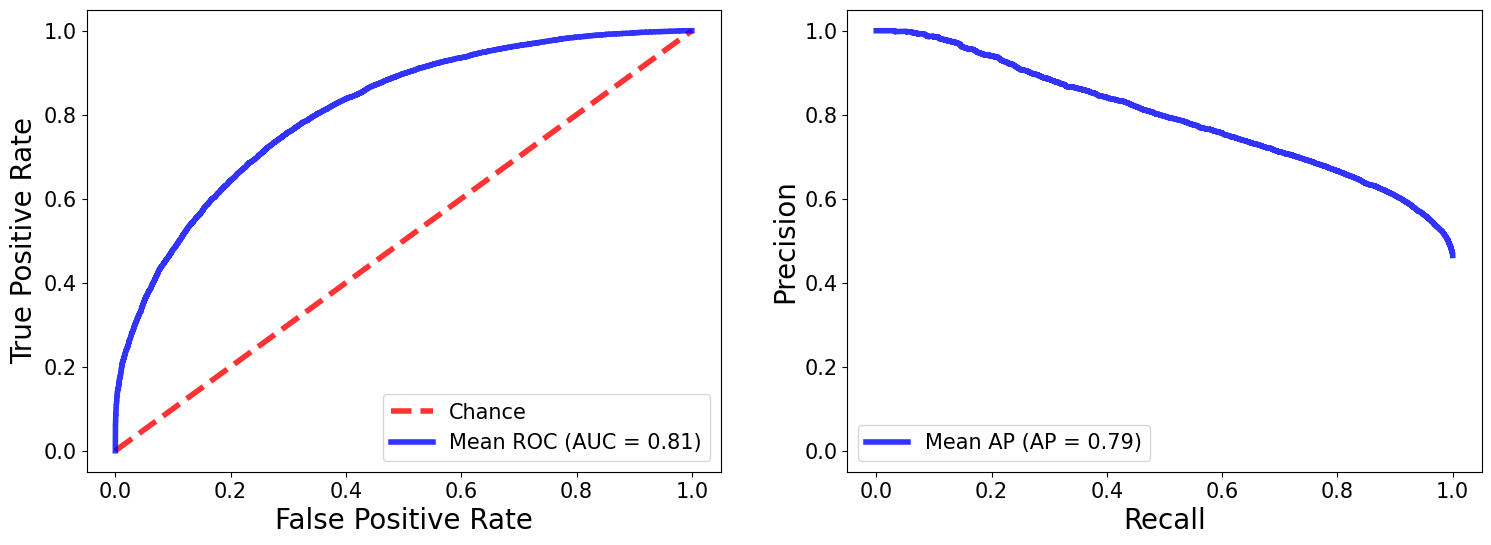

,Fold,Accuracy,Precision,Recall,F1-Score,MCC
0,Fold 0,0.747418,0.726368,0.732616,0.729479,0.492628
1,Fold 1,0.732089,0.706499,0.724731,0.715499,0.462562
2,Fold 2,0.758081,0.758301,0.703943,0.730112,0.512619
3,Fold 3,0.707098,0.684549,0.686022,0.685285,0.411369
4,Fold 4,0.760080,0.750557,0.724731,0.737418,0.516952
5,Fold 5,0.715428,0.698459,0.682437,0.690355,0.427264
6,Fold 6,0.761413,0.736585,0.757706,0.746996,0.521543
7,Fold 7,0.691769,0.678571,0.640143,0.658797,0.378697
8,Fold 8,0.717428,0.703044,0.678853,0.690737,0.430984
9,Fold 9,0.695102,0.693237,0.617204,0.653015,0.384782


In [11]:

plot_au_curves(test_cv_results)
calculate_cv_results(test_cv_results)

Baseline Accuracy: 0.7500833055648117
0 HRV__ar_coefficient__coeff_5__k_10 0.006997667444185285
1 HRV__fft_coefficient__attr_abs__coeff_5 0.003998667110962972
2 HRV__fft_coefficient__attr_abs__coeff_56 0.0006664445184938472
3 HRV__fft_coefficient__attr_real__coeff_28 0.0
4 HRV__partial_autocorrelation__lag_5 0.0036654448517160487
5 HRV__fft_coefficient__attr_angle__coeff_67 0.0023325558147284653
6 HRV__partial_autocorrelation__lag_2 0.005331556147950667
7 HRV__fft_coefficient__attr_abs__coeff_45 0.001666111296234618
8 HRV__ar_coefficient__coeff_1__k_10 0.004998333888703743
9 HRV__fft_coefficient__attr_angle__coeff_77 -0.0006664445184938472
10 HRV__fft_coefficient__attr_imag__coeff_47 0.0
11 HRV__fft_coefficient__attr_real__coeff_83 -0.001666111296234618
12 HRV__fft_coefficient__attr_abs__coeff_66 -0.0029990003332223125
13 HRV__fft_coefficient__attr_real__coeff_61 -0.0023325558147284653
14 HRV__fft_coefficient__attr_abs__coeff_29 0.007664111962679132
15 HRV__fft_coefficient__attr_abs__c

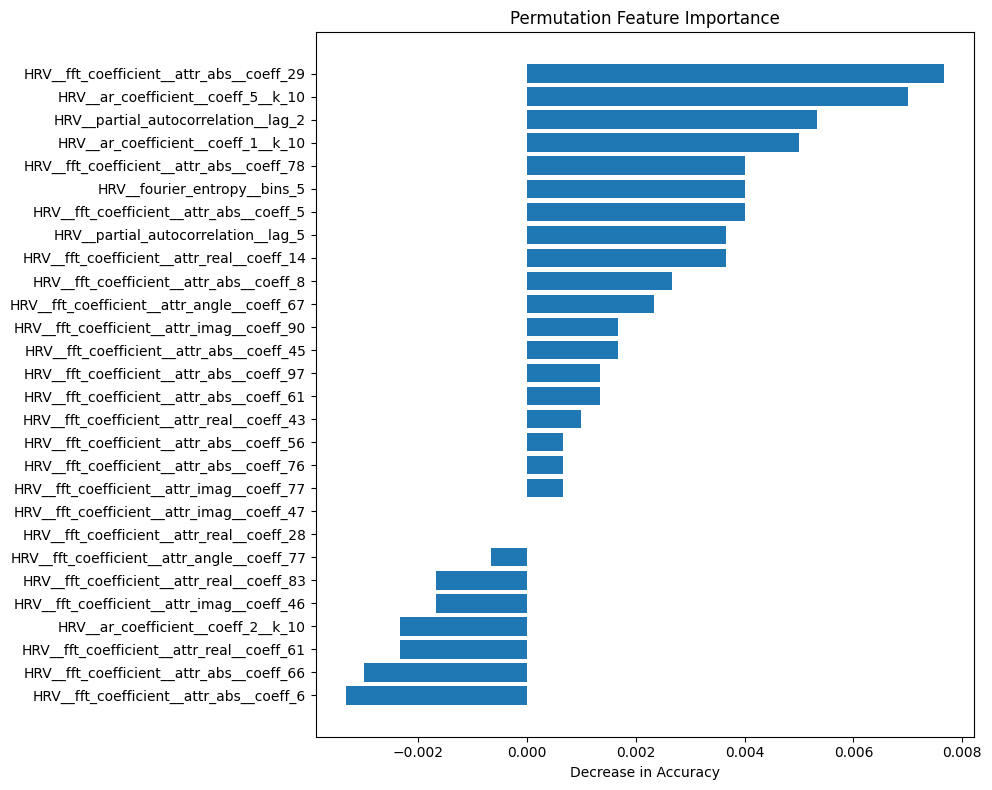

In [13]:
## Model Explainability using permutation feature importance (PFI)

feature_names = [
    "HRV__ar_coefficient__coeff_5__k_10",
    "HRV__fft_coefficient__attr_abs__coeff_5",
    "HRV__fft_coefficient__attr_abs__coeff_56",
    "HRV__fft_coefficient__attr_real__coeff_28",
    "HRV__partial_autocorrelation__lag_5",
    "HRV__fft_coefficient__attr_angle__coeff_67",
    "HRV__partial_autocorrelation__lag_2",
    "HRV__fft_coefficient__attr_abs__coeff_45",
    "HRV__ar_coefficient__coeff_1__k_10",
    "HRV__fft_coefficient__attr_angle__coeff_77",
    "HRV__fft_coefficient__attr_imag__coeff_47",
    "HRV__fft_coefficient__attr_real__coeff_83",
    "HRV__fft_coefficient__attr_abs__coeff_66",
    "HRV__fft_coefficient__attr_real__coeff_61",
    "HRV__fft_coefficient__attr_abs__coeff_29",
    "HRV__fft_coefficient__attr_abs__coeff_6",
    "HRV__fft_coefficient__attr_imag__coeff_77",
    "HRV__ar_coefficient__coeff_2__k_10",
    "HRV__fft_coefficient__attr_imag__coeff_46",
    "HRV__fft_coefficient__attr_abs__coeff_61",
    "HRV__fft_coefficient__attr_imag__coeff_90",
    "HRV__fourier_entropy__bins_5",
    "HRV__fft_coefficient__attr_real__coeff_14",
    "HRV__fft_coefficient__attr_abs__coeff_97",
    "HRV__fft_coefficient__attr_abs__coeff_78",
    "HRV__fft_coefficient__attr_real__coeff_43",
    "HRV__fft_coefficient__attr_abs__coeff_8",
    "HRV__fft_coefficient__attr_abs__coeff_76"
]

from sklearn.metrics import accuracy_score

baseline_pred = model.predict(
    [X_test, X_features_test],
    verbose=0
)

baseline_pred = (baseline_pred.flatten() > 0.5).astype(int)

baseline_acc = accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline Accuracy:", baseline_acc)

importance = []

rng = np.random.default_rng(42)

for feature_idx in range(X_features_test.shape[1]):

    X_perm = X_features_test.copy()

    rng.shuffle(X_perm[:, feature_idx])

    pred = model.predict(
        [X_test, X_perm],
        verbose=0
    )

    pred = (pred.flatten() > 0.5).astype(int)

    acc = accuracy_score(
        y_test,
        pred
    )

    importance.append(baseline_acc - acc)

    print(feature_idx,
          feature_names[feature_idx],
          baseline_acc - acc)

importance = np.array(importance)

indices = np.argsort(importance)[::-1]

plt.figure(figsize=(10,8))

plt.barh(
    np.array(feature_names)[indices],
    importance[indices]
)

plt.xlabel("Decrease in Accuracy")

plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()